In [2]:
# VLM 추론에 필요한 package를 설치합니다.
!pip -q install huggingface_hub accelerate "pillow<12.0"
!pip -q install transformers==5.9.0
!pip -q install gdown

!echo "설치가 끝났습니다."

설치가 끝났습니다.


In [3]:
# local VLM 모델과 processor를 로드합니다.
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText

# 다른 VLM으로 바꾸려면 이 한 줄만 교체하세요.
VLM_MODEL = "google/gemma-4-E2B-it"

# cuda가 사용 가능하다면 모델의 GPU/CPU 배치를 자동으로 정하게 합니다.
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(VLM_MODEL)
model = AutoModelForImageTextToText.from_pretrained(
    VLM_MODEL,
).to(device)
print("model loaded:", VLM_MODEL)

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 10.2GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

model loaded: google/gemma-4-E2B-it


In [4]:
import re


# 이미지와 prompt를 모델에 넣고 답변을 생성합니다.
def run_vlm(image_path, prompt, model=model, processor=processor, max_new_tokens=1024, enable_thinking=True):
    image = Image.open(image_path).convert("RGB")
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }]
    # chat template은 role/content 메시지를 모델이 학습된 대화 형식의 token 입력으로 바꿉니다.
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    ).to(model.device)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    generated_ids = output_ids[0][input_len:]
    clean = processor.decode(generated_ids, skip_special_tokens=True).strip()
    raw = processor.decode(generated_ids, skip_special_tokens=False).strip()
    return {"clean": clean, "raw": raw}


# 모델 출력에서 <answer>...</answer> 안쪽 값만 꺼냅니다.
# 태그가 없으면 전체 텍스트를 그대로 돌려줘서, 아래 parse_choice가 단어 매칭을 시도할 수 있게 합니다.
def extract_answer_value(text):
    text = str(text).strip()
    match = re.search(r"<answer>\s*(.*?)\s*</answer>", text, flags=re.I | re.S)
    if match:
        return match.group(1).strip()
    return text


# 모델 답에서 보기 문자(A~D)나 보기 단어를 찾아 (문자, 선택지 텍스트)로 정리합니다.
# 간단한 규칙 기반 매칭이므로, 답이 특이한 형식이면 (None, 모델 답 원문)을 돌려줍니다.
def parse_choice(model_text, choices):
    ans = extract_answer_value(model_text)
    labels = [chr(ord("A") + i) for i in range(len(choices))]
    a = str(ans).strip().upper()
    # 1) "B", "B.", "B)" 처럼 보기 문자로 답한 경우
    for i, label in enumerate(labels):
        if a == label or a.startswith(label + ".") or a.startswith(label + ")"):
            return label, choices[i]
    # 2) 문자 대신 "Stop"처럼 보기 단어로 답한 경우
    for i, choice in enumerate(choices):
        if choice.lower() in str(ans).lower():
            return labels[i], choice
    return None, str(ans)


print("슝~")

슝~


In [5]:
# 실습 전반에서 사용할 package와 데이터 경로를 준비합니다.
import os
import glob
import random

HOME = os.environ.get('HOME')
WORK_DIR = os.path.join(HOME, 'work')
DATA_DIR = os.path.join(WORK_DIR, 'datasets')
DATA_ROOT = os.path.join(DATA_DIR, 'vlm_data')
RESULT_DIR = os.path.join(WORK_DIR, 'results')

DATA_URL = "https://drive.google.com/file/d/1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl/view?usp=drive_link"
DATA_ZIP = os.path.join(DATA_DIR, 'vlm_data.zip')
# 공유 링크에서 파일 ID만 뽑아 gdown이 바로 받을 수 있는 주소로 바꿉니다.
DATA_ID = DATA_URL.split("/d/")[1].split("/")[0]
DOWNLOAD_URL = "https://drive.google.com/uc?id=" + DATA_ID
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

In [6]:
# 자율주행 샘플 데이터(이미지 10장)를 구글 드라이브에서 받습니다.
!gdown "{DOWNLOAD_URL}" -O "{DATA_ZIP}"
!unzip -q -o "{DATA_ZIP}" -d "{DATA_ROOT}"

Downloading...
From: https://drive.google.com/uc?id=1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl
To: /root/work/datasets/vlm_data.zip
100% 7.73M/7.73M [00:00<00:00, 48.8MB/s]


In [7]:
# 이미지를 모두 찾아 랜덤하게 섞습니다.
image_paths = [p for p in glob.glob(os.path.join(DATA_ROOT, "**", "*"), recursive=True)
               if os.path.splitext(p)[1].lower() in (".jpg", ".jpeg", ".png")]
random.shuffle(image_paths)
print("받은 이미지 수:", len(image_paths))

받은 이미지 수: 10


In [9]:
# 고정 질문과 보기 (영어, 객관식)
FIXED_QUESTION = "Based on the situation shown in the image, what is the most appropriate action for the vehicle to take right now?"
FIXED_CHOICES = ["Go", "Stop", "Cannot be determined", "None of the above"]


# 질문·보기·판단 기준을 합쳐 모델에 넣을 prompt를 만듭니다.
def build_action_prompt(question=FIXED_QUESTION, choices=FIXED_CHOICES):
    labels = [chr(ord("A") + i) for i in range(len(choices))]
    option_lines = "\n".join(f"{label}. {choice}" for label, choice in zip(labels, choices))
    return (
        "You are a driving assistant. Look at the image taken from a vehicle and decide whether the vehicle should keep moving (Go) or stop (Stop), judging by collision risk.\n\n"
        "Ask yourself: if the vehicle moves forward now, could it collide with a person or another vehicle? Everything visible in the image is within the vehicle's reach, so do not dismiss something just because it is off to the side or not directly ahead.\n"
        "People (pedestrians or cyclists) can move unpredictably, so if any person appears in the scene, treat it as a real collision risk. A vehicle is a collision risk when it is close or large in the view; a small, distant, or clearly parked vehicle that you could pass safely is not.\n"
        "Choose Stop when there is a real risk of collision, and choose Go only when the way is clearly safe.\n\n"
        "Question: " + question.strip() + "\n\n"
        "Options:\n" + option_lines + "\n\n"
        "First explain your reasoning in one or two sentences based on what you actually see, then give your final choice as the single option letter (" + ", ".join(labels) + ") inside <answer>...</answer>."
    )


PROMPT_TEXT = build_action_prompt()
print(PROMPT_TEXT)

You are a driving assistant. Look at the image taken from a vehicle and decide whether the vehicle should keep moving (Go) or stop (Stop), judging by collision risk.

Ask yourself: if the vehicle moves forward now, could it collide with a person or another vehicle? Everything visible in the image is within the vehicle's reach, so do not dismiss something just because it is off to the side or not directly ahead.
People (pedestrians or cyclists) can move unpredictably, so if any person appears in the scene, treat it as a real collision risk. A vehicle is a collision risk when it is close or large in the view; a small, distant, or clearly parked vehicle that you could pass safely is not.
Choose Stop when there is a real risk of collision, and choose Go only when the way is clearly safe.

Question: Based on the situation shown in the image, what is the most appropriate action for the vehicle to take right now?

Options:
A. Go
B. Stop
C. Cannot be determined
D. None of the above

First expl

In [10]:
from tqdm.auto import tqdm

rows = []
for path in tqdm(image_paths, desc="VLM 추론"):
    result = run_vlm(path, PROMPT_TEXT)
    letter, choice_text = parse_choice(result["clean"], FIXED_CHOICES)

    # 파일 이름에서 정답을 얻습니다. (go가 있으면 go, stop이 있으면 stop)
    name = os.path.basename(path).lower()
    true_label = "go" if "go" in name else ("stop" if "stop" in name else "unknown")
    pred_label = choice_text.lower()

    rows.append({
        "image": os.path.basename(path),
        "label": true_label,
        "answer": choice_text,
        "correct": pred_label == true_label,
        "reasoning": result["clean"],
    })
print("추론 완료!")

VLM 추론:   0%|          | 0/10 [00:00<?, ?it/s]

추론 완료!


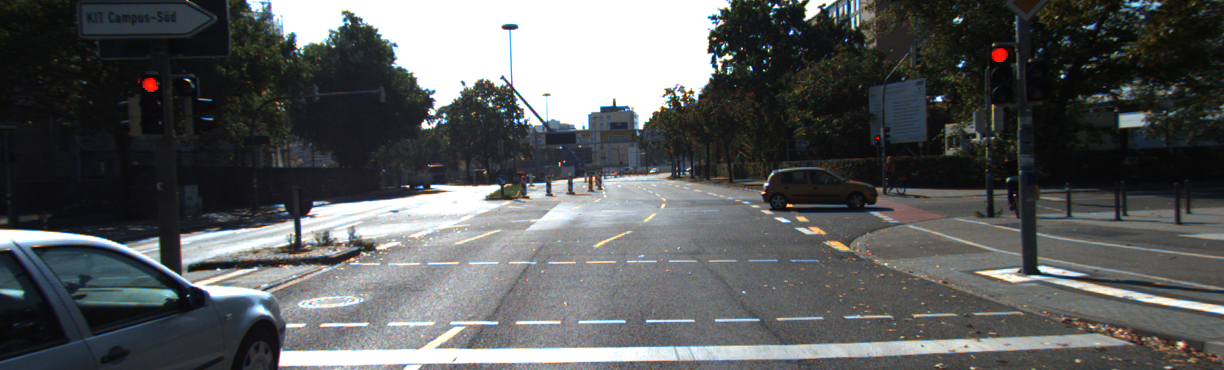

이미지: stop_3.png
정답(label): stop
VLM 선택: Stop (정답 여부: True )

=== VLM의 reasoning ===
thought
1.  **Analyze the image:** The image shows a street scene, likely in an urban or suburban area. It is taken from a vehicle (implied by the perspective). There is a road, traffic lights (one visible, red), trees, buildings, and other vehicles.

2.  **Identify relevant elements for collision risk:**
    *   **Road conditions:** Clear road markings.
    *   **Traffic signals:** The traffic light visible on the left side appears to be red (or at least, the light facing the camera seems to be red, though the specific state of the light controlling the direction of travel is crucial).
    *   **Vehicles:** There is a brown/gold sedan driving in the distance/middle ground. There is a silver car in the foreground (the viewpoint vehicle).
    *   **Pedestrians/Cyclists:** I need to scan carefully for people. I do not see any clearly visible pedestrians or cyclists in the immediate path or near the crossw

In [13]:
# 결과 하나를 골라 이미지와 reasoning을 출력합니다.
from IPython.display import display, Image as IPImage

# i 를 변경하여 데이터를 확인 할 수 있습니다
i = 0
display(IPImage(filename=image_paths[i]))
print("이미지:", rows[i]["image"])
print("정답(label):", rows[i]["label"])
print("VLM 선택:", rows[i]["answer"], "(정답 여부:", rows[i]["correct"], ")")
print()
print("=== VLM의 reasoning ===")
print(rows[i]["reasoning"])

In [14]:
import pandas as pd

df = pd.DataFrame(rows)
acc = df["correct"].mean() * 100
print(f"정확도: {acc:.1f}%  ({df['correct'].sum()}/{len(df)})")

# reasoning까지 모두 담아 CSV로 저장합니다.
RESULT_CSV = os.path.join(RESULT_DIR, "vlm_results.csv")
df.to_csv(RESULT_CSV, index=False, encoding="utf-8-sig")
print("저장 완료:", RESULT_CSV)

# 표에는 답만 간단히 보여 줍니다. (reasoning은 CSV에서 확인)
df[["image", "label", "answer", "correct"]]

정확도: 80.0%  (8/10)
저장 완료: /root/work/results/vlm_results.csv


,image,label,answer,correct
0,stop_3.png,stop,Stop,True
1,go_5.png,go,Go,True
2,stop_2.png,stop,Stop,True
3,go_3.png,go,Go,True
4,stop_5.png,stop,Go,False
5,stop_1.png,stop,Stop,True
6,go_1.png,go,Go,True
7,go_2.png,go,Go,True
8,go_4.png,go,Go,True
9,stop_4.png,stop,Go,False
